In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset

In [5]:
file_path = "/content/Sales Data Analysis .xlsx"

df = pd.read_excel('/content/Sales Data Analysis .xlsx')


# Convert columns

In [6]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")
df["Qty"] = pd.to_numeric(df["Qty"], errors="coerce").fillna(0)


/tmp/ipykernel_2400/3109920623.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


# Completed sales

In [7]:
completed = df[
    (df["Status"] == "Shipped - Delivered to Buyer") &
    (df["Amount"].notna())
].copy()

# KPI ANALYSIS

In [8]:
total_revenue = completed["Amount"].sum()
total_orders = completed["Order ID"].nunique()
average_order_value = total_revenue / total_orders
total_units = completed["Qty"].sum()

top_category = (
    completed.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

best_product = (
    completed.groupby("Style")["Amount"]
    .sum()
    .sort_values(ascending=False)
    .index[0]
)

kpi = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Total Units Sold",
        "Top Category",
        "Best Product"
    ],
    "Result": [
        total_revenue,
        total_orders,
        average_order_value,
        total_units,
        top_category,
        best_product
    ]
})

print(kpi)

                   KPI      Result
0        Total Revenue  18650815.0
1         Total Orders       26566
2  Average Order Value  702.055823
3     Total Units Sold       28886
4         Top Category         Set
5         Best Product     JNE3797


# MONTHLY TREND

In [9]:
monthly = (
    completed.groupby(completed["Date"].dt.to_period("M"))
    .agg(
        Revenue=("Amount", "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum")
    )
)

monthly["Growth %"] = monthly["Revenue"].pct_change() * 100

print(monthly)

           Revenue  Orders  Units    Growth %
Date                                         
2022-01   547137.0     806    863         NaN
2022-02   586804.0     850    918    7.249921
2022-03   585949.0     867    922   -0.145705
2022-04  5628226.0    8311   9137  860.531719
2022-05  4647942.0    6416   7011  -17.417282
2022-06  2609344.0    3650   3909  -43.860229
2022-07   692323.0     967   1055  -73.467546
2022-08   654726.0     918    990   -5.430558
2022-09   632167.0     898    963   -3.445563
2022-10   686574.0     966   1045    8.606428
2022-11   700847.0     963   1043    2.078873
2022-12   678776.0     954   1030   -3.149189


# CATEGORY ANALYSIS

In [10]:
category_sales = (
    completed.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

Category
Set              8800562.0
kurta            4715208.0
Western Dress    3868616.0
Top               948734.0
Ethnic Dress      165465.0
Blouse             85444.0
Bottom             48615.0
Saree              18171.0
Name: Amount, dtype: float64


# STATE ANALYSIS

In [11]:
state_sales = (
    completed.groupby("ship-state")
    .agg(
        Revenue=("Amount", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

print(state_sales.head(10))

                  Revenue  Orders
ship-state                       
MAHARASHTRA     3135062.0    4582
KARNATAKA       2279856.0    3350
UTTAR PRADESH   1669881.0    2282
TELANGANA       1551447.0    2140
TAMIL NADU      1466364.0    2197
KERALA          1079132.0    1567
DELHI           1009947.0    1406
ANDHRA PRADESH   772127.0    1084
WEST BENGAL      749127.0    1139
Gujarat          732260.0    1035


# CITY ORDER DENSITY

In [12]:
city_orders = (
    completed.groupby("ship-city")["Order ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(city_orders.head(10))

ship-city
BENGALURU    2136
HYDERABAD    1488
MUMBAI       1308
NEW DELHI    1211
CHENNAI       968
PUNE          771
KOLKATA       457
GURUGRAM      350
THANE         337
LUCKNOW       328
Name: Order ID, dtype: int64


# BEST PRODUCTS

In [13]:
product_sales = (
    completed.groupby("Style")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(product_sales.head(10))


Style
JNE3797    1416359.0
J0003       385881.0
J0341       352947.0
JNE3798     288786.0
JNE3800     261683.0
SET183      239588.0
SET397      216760.0
SET363      184737.0
J0230       183429.0
SET398      183076.0
Name: Amount, dtype: float64


# DELIVERY STATUS ANALYSIS

In [14]:

status_analysis = (
    df.groupby("Status")
    .agg(
        Orders=("Order ID", "nunique"),
        Revenue=("Amount", "sum"),
        Units=("Qty", "sum")
    )
    .sort_values("Revenue", ascending=False)
)

print(status_analysis)

                               Orders     Revenue  Units
Status                                                  
Shipped                         72826  50324255.0  78009
Shipped - Delivered to Buyer    26566  18650815.0  28886
Cancelled                       17185   6919284.3   5657
Shipped - Returned to Seller     1851   1269644.0   1970
Shipped - Picked Up               918    661252.0    977
Pending                           584    430271.0    657
Pending - Waiting for Pick Up     262    192138.0    283
Shipped - Returning to Seller     130    107620.0    150
Shipped - Out for Delivery         32     26971.0     35
Shipped - Rejected by Buyer        11      7295.0     11
Shipped - Lost in Transit           4      1997.0      5
Shipped - Damaged                   1      1136.0      1
Shipping                            8         0.0      8


# B2B ANALYSIS

In [15]:
b2b_analysis = (
    completed.groupby("B2B")
    .agg(
        Revenue=("Amount", "sum"),
        Orders=("Order ID", "nunique"),
        Units=("Qty", "sum")
    )
)

print(b2b_analysis)

          Revenue  Orders  Units
B2B                             
False  18468552.0   26349  28629
True     182263.0     217    257


# VISUALIZATION

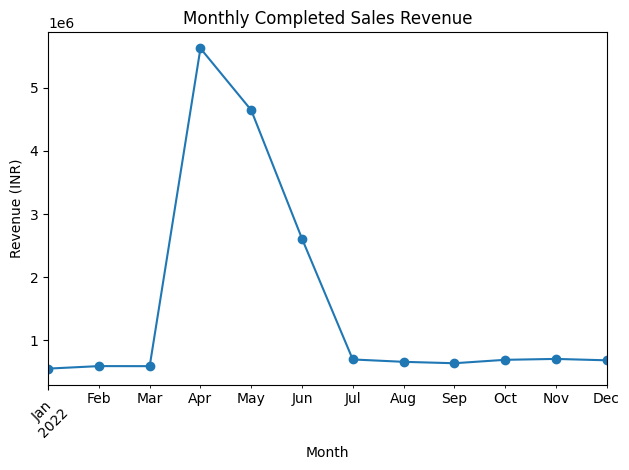

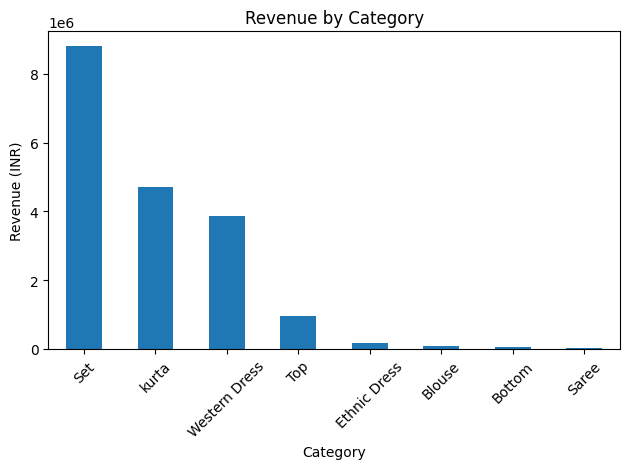

In [16]:
monthly["Revenue"].plot(kind="line", marker="o")
plt.title("Monthly Completed Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()